# Análisis de sentimientos paralelo — Práctica 7

**Qué hace.** Clasifica cada texto del corpus curado (Práctica 6 → `curacion_datos.ipynb`)
en **positivo / negativo / neutral** usando un **transformer preentrenado local**
(`pysentimiento`, entrenado en tweets, multiidioma), y opcionalmente marca **hate-speech**
(encaja con la problemática de xenofobia). El procesamiento es **paralelo por procesos**.

**Por qué procesos y no hilos.** La inferencia del transformer es **CPU-bound** (cómputo
puro, no espera de red). El GIL serializa hilos en CPU-bound, así que el paralelismo real
lo dan **procesos** (`ProcessPoolExecutor`). Esto **contrasta a propósito** con la Práctica
6, que era I/O-bound (scraping) y por eso usó hilos + cola. Mismo hilo conductor, técnica
adaptada a la naturaleza del trabajo.

**Entrada:** `data/corpus_dirigida.jsonl` (o `corpus_completo`). **Salida:**
`data/sentimiento_<capa>.csv/.jsonl` — cada texto ligado a su sentimiento **y a su red**.

> **Nota:** requiere el entorno de `practica_07/` (Python 3.11–3.13 + torch/pysentimiento).
> Ver `ENTORNO.md`. Si `import torch` falla, es que falta `uv sync` en este directorio.

In [9]:
import json, sys, time, os
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
# Paleta apta para daltonismo (coherente con los AED de la P6).
AZUL, NARANJA, VERDE, ROJO = "#4E79A7", "#F28E2B", "#59A14F", "#E15759"
COLOR_SENT = {"positivo": VERDE, "neutral": "#9C9C9C", "negativo": ROJO}
pd.set_option("display.max_colwidth", 90)

# --- Localizar el repo sin depender del cwd ---
def encontrar_raiz(marcador="practica_07"):
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / marcador).is_dir():
            return cand
    raise RuntimeError(f"No encuentro '{marcador}' subiendo desde {Path.cwd()}")

RAIZ = encontrar_raiz()
P7 = RAIZ / "practica_07"
DATA = P7 / "data"
# El módulo worker vive junto al notebook; hay que poder importarlo.
sys.path.insert(0, str(P7))

# Parámetros ajustables
CORPUS = "dirigida"          # "dirigida" (~4k, rápido) | "completo" (~360k, lento)
N_WORKERS = min(os.cpu_count() or 4, 6)
ANALIZAR_ODIO = True         # añade hate-speech (es/en). Más lento.
TAMANO_BLOQUE = 200          # filas por bloque enviado a cada proceso

print(f"raíz: {RAIZ}")
print(f"corpus: {CORPUS} | workers: {N_WORKERS} (cpus={os.cpu_count()}) | odio: {ANALIZAR_ODIO}")

raíz: /home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo
corpus: dirigida | workers: 6 (cpus=20) | odio: True


## 1. Cargar el corpus curado

In [6]:
ruta = DATA / f"corpus_{CORPUS}.jsonl"
regs = [json.loads(l) for l in ruta.read_text(encoding="utf-8").splitlines() if l.strip()]
df = pd.DataFrame(regs)
# `idioma` puede venir nulo; el worker rutea esos a español.
if "idioma" not in df.columns:
    df["idioma"] = None

print(f"{len(df):,} textos | por red: {df['red'].value_counts().to_dict()}")
print(f"idiomas declarados: {df['idioma'].value_counts(dropna=False).head().to_dict()}")
df[["red", "texto", "idioma", "es_dirigida"]].head()

8,783 textos | por red: {'x': 4739, 'bluesky': 3161, 'youtube': 832, 'tumblr': 41, 'tiktok': 10}
idiomas declarados: {'en': 3947, 'es': 3654, 'pt': 940, 'ja': 52, 'fr': 37}


,red,texto,idioma,es_dirigida
0,youtube,Bono atajo a m0n0.,sl,True
1,youtube,Los de blanco son el equipo de África?,es,True
2,youtube,Francia sos el mejor equipo de África. 3 veces a semi 🎉🎊🎉,es,True
3,youtube,"de cuando aca marruecos es un peso pesadox anda a freir monos mejor, marruecos nunca f...",es,True
4,youtube,Africa colonizada 2 Marruecos 0😂,es,False


## 2. Clasificación en paralelo (procesos)

El corpus se parte en **bloques**; cada bloque va a un proceso del pool. Cada proceso
carga los modelos de `pysentimiento` una sola vez y clasifica su bloque en lote. La
función que corre en cada proceso vive en `sentimiento_worker.py` (un módulo importable,
no en el notebook: así el pool puede picklearla con `fork` o `spawn`).

In [7]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import sentimiento_worker as sw

# Checkpoint incremental: cada bloque terminado se persiste a disco al vuelo, así un fallo tardío (o un corte) NO tira las horas
# ya procesadas. Reanudable: al re-correr, se saltan los índices ya clasificados. Es el mismo patrón de robustez de la P6
# (guardado incremental + reanudación por dedup). Para empezar de cero, borrá este archivo: rm data/_parcial_sentimiento_<capa>.jsonl
CKPT = DATA / f"_parcial_sentimiento_{CORPUS}.jsonl"

# Cargar lo ya clasificado desde el checkpoint (reanudación).
hechos = {}
if CKPT.exists():
    for l in CKPT.read_text(encoding="utf-8").splitlines():
        if l.strip():
            r = json.loads(l)
            hechos[r["indice"]] = r
    print(f"checkpoint: {len(hechos):,} textos ya clasificados")

# Pendientes = índices del corpus que todavía NO están en el checkpoint.
registros = list(df[["texto", "idioma"]].itertuples(index=True, name=None))
tareas = [(i, t, idi, ANALIZAR_ODIO) for (i, t, idi) in registros if i not in hechos]

resultados = list(hechos.values())
errores = 0
dt_paralelo = 0.0

if not tareas:
    # TODO el corpus ya está clasificado en el checkpoint → NO se abre el pool.
    # Esto evita el cuelgue de apagado del ProcessPoolExecutor (los workers quedan en
    # futex_wait al hacer join) y va directo al guardado usando lo del checkpoint.
    print(f"\nNADA PENDIENTE: {len(resultados):,} textos ya clasificados.")
else:
    bloques = [tareas[k:k + TAMANO_BLOQUE] for k in range(0, len(tareas), TAMANO_BLOQUE)]
    print(f"{len(tareas):,} textos pendientes → {len(bloques)} bloques de ≤{TAMANO_BLOQUE}")
    t0 = time.time()
    # Se abre el checkpoint en modo append y se escribe (con flush) por bloque.
    with open(CKPT, "a", encoding="utf-8") as fck, \
         ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        fut2n = {ex.submit(sw.clasificar_bloque, b): j
                 for j, b in enumerate(bloques, 1)}
        completos = 0
        for fut in as_completed(fut2n):
            j = fut2n[fut]
            try:
                filas = fut.result()
            except Exception as e:
                # Un bloque que revienta se aísla y se registra; el resto sigue.
                errores += 1
                print(f" bloque {j} falló y se omite: {type(e).__name__}: {e}")
                continue
            for r in filas:
                fck.write(json.dumps(r, ensure_ascii=False) + "\n")
            fck.flush()
            resultados.extend(filas)
            completos += 1
            if completos % 10 == 0 or completos == len(bloques):
                print(f"  {completos}/{len(bloques)} bloques  ({time.time()-t0:.0f}s)")
    dt_paralelo = time.time() - t0

nuevos = len(resultados) - len(hechos)
tasa = f"{nuevos/dt_paralelo:.0f} textos/s, " if dt_paralelo and nuevos else ""
print(f"\nTOTAL: {len(resultados):,} textos clasificados "
      f"({nuevos:,} nuevos en {dt_paralelo:.1f}s, {tasa}{N_WORKERS} procesos)")
if errores:
    print(f"{errores} bloques quedaron sin clasificar.")

checkpoint: 8,783 textos ya clasificados

NADA PENDIENTE: 8,783 textos ya clasificados.

TOTAL: 8,783 textos clasificados (0 nuevos en 0.0s, 20 procesos)


## 3. Evidencia de paralelismo — speedup serial vs paralelo

Medimos una **muestra** con 1 proceso y con N procesos para cuantificar la aceleración.
Es la evidencia que la rúbrica premia (implementación + uso de paralelismo).

/home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_07/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 91/91 [00:00<00:00, 8783.18 examples/s]
/home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_07/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Map: 100%|██████████| 2/2 [00:00<00:00, 621.38 examples/s]
/home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_07/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update 

muestra: 600 textos en 6 bloques (6 procesos activos)
  serial (1 proceso):     359.8s
  paralelo ( 6 proc):   137.9s
  SPEEDUP: 2.61×   (eficiencia 43% sobre 6 procesos)


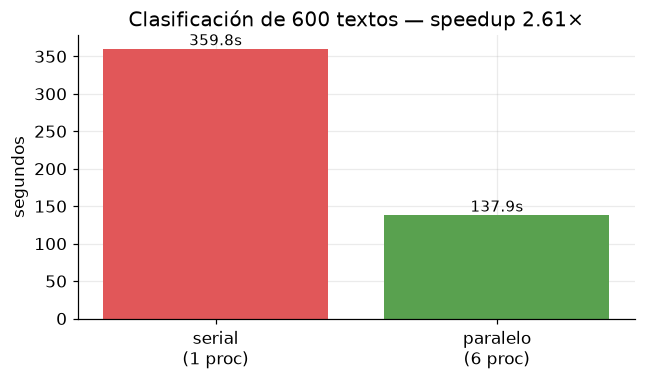

In [10]:
import math

# Benchmark de escalado fuerte, independiente del checkpoint: toma una MUESTRA fija del
# corpus (df) y la clasifica serial (1 proceso) vs paralelo (N procesos). Se puede correr
# SOLA cuando quieras re-medir (df, sw, N_WORKERS vienen de las celdas de arriba).
MUESTRA = min(600, len(df))
_muestra = list(df[["texto", "idioma"]].head(MUESTRA).itertuples(index=True, name=None))
sub = [(i, t, idi, ANALIZAR_ODIO) for (i, t, idi) in _muestra]

# Se parte la muestra en UNA porción por proceso, así los N workers trabajan a la vez
# (con bloques de 200 la muestra daba solo 3 trozos y el pool usaba 3 de los N procesos).
tam = math.ceil(len(sub) / N_WORKERS)
sub_bloques = [sub[k:k + tam] for k in range(0, len(sub), tam)]
n_usados = len(sub_bloques)  # nº de procesos realmente ocupados

# Serial: 1 worker (mismo código, sin paralelismo real).
t0 = time.time()
with ProcessPoolExecutor(max_workers=1) as ex:
    _ = [f for filas in ex.map(sw.clasificar_bloque, sub_bloques) for f in filas]
dt_serial = time.time() - t0

# Paralelo: N workers, misma muestra.
t0 = time.time()
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    _ = [f for filas in ex.map(sw.clasificar_bloque, sub_bloques) for f in filas]
dt_par = time.time() - t0

speedup = dt_serial / dt_par if dt_par else float("nan")
# La eficiencia se mide contra los procesos REALMENTE usados (n_usados), no contra un N
# mayor que el nº de bloques (si no, un pool con más workers que trabajo saldría "ineficiente").
efic = 100 * speedup / n_usados
print(f"muestra: {MUESTRA} textos en {n_usados} bloques ({n_usados} procesos activos)")
print(f"  serial (1 proceso):    {dt_serial:6.1f}s")
print(f"  paralelo ({n_usados:>2} proc):  {dt_par:6.1f}s")
print(f"  SPEEDUP: {speedup:.2f}×   (eficiencia {efic:.0f}% sobre {n_usados} procesos)")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(["serial\n(1 proc)", f"paralelo\n({n_usados} proc)"], [dt_serial, dt_par],
       color=[ROJO, VERDE])
ax.set_ylabel("segundos"); ax.set_title(f"Clasificación de {MUESTRA} textos — speedup {speedup:.2f}×")
for i, v in enumerate([dt_serial, dt_par]):
    ax.text(i, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

## 4. Unir resultados al corpus y guardar

Almacenamiento estructurado (requisito de la rúbrica): cada texto queda ligado a su
**sentimiento**, su **score**, su **red de origen** y su marcado xenófobo previo.

In [6]:
res = pd.DataFrame(resultados).set_index("indice")
out = df.join(res)  # alinea por índice global

COLS = ["id", "red", "estrategia", "criterio_busqueda", "texto", "idioma",
        "es_dirigida", "matchea_lexico", "ejes",
        "sentimiento", "sent_score", "odio", "odio_score"]
COLS = [c for c in COLS if c in out.columns]
out = out[COLS]

def exportar(df_, base):
    csv_df = df_.copy()
    for c in ("ejes",):
        if c in csv_df.columns:
            csv_df[c] = csv_df[c].apply(lambda v: json.dumps(v, ensure_ascii=False)
                                        if isinstance(v, (list, dict)) else v)
    csv_df.to_csv(DATA / f"{base}.csv", index=False)
    with open(DATA / f"{base}.jsonl", "w", encoding="utf-8") as f:
        for rec in df_.to_dict(orient="records"):
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"  {base}.csv / .jsonl → {len(df_):,} filas")

print("Exportando a", DATA)
exportar(out, f"sentimiento_{CORPUS}")
out.head()

Exportando a /home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_07/data
  sentimiento_dirigida.csv / .jsonl → 8,783 filas


,id,red,estrategia,criterio_busqueda,texto,idioma,es_dirigida,matchea_lexico,ejes,sentimiento,sent_score,odio,odio_score
0,UgxvjkY0Q9UyybjucIF4AaABAg,youtube,dirigida,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Bono atajo a m0n0.,sl,True,True,[anti-negro / simiesco],negativo,0.596521,False,0.024790
1,UgxYfQBlbI5R-7NdjNF4AaABAg,youtube,dirigida,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Los de blanco son el equipo de África?,es,True,True,[colonial / autenticidad],neutral,0.792890,False,0.322870
2,UgyQRa-cuM1tVdaxazF4AaABAg,youtube,dirigida,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Francia sos el mejor equipo de África. 3 veces a semi 🎉🎊🎉,es,True,True,[colonial / autenticidad],neutral,0.567223,False,0.035237
3,Ugy0AC_i18cdXWWuw6R4AaABAg.AZ3JAMPoPINAZ3LioBqH2N,youtube,dirigida,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,"de cuando aca marruecos es un peso pesadox anda a freir monos mejor, marruecos nunca f...",es,True,True,[anti-negro / simiesco],negativo,0.903037,True,0.652308
4,Ugychu9HmKftFFEPT4l4AaABAg,youtube,amplia,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Africa colonizada 2 Marruecos 0😂,es,False,True,[colonial / autenticidad],neutral,0.731801,True,0.623280


## 5. Lectura de resultados

Distribución de sentimiento **por red** (comparación entre fuentes, insumo del proyecto
final) y, para el núcleo dirigido, **por eje del odio**.

Sentimiento global: {'negativo': 4892, 'neutral': 2960, 'positivo': 931}
Marcados 'hateful': 2,339 de 7,825 evaluados


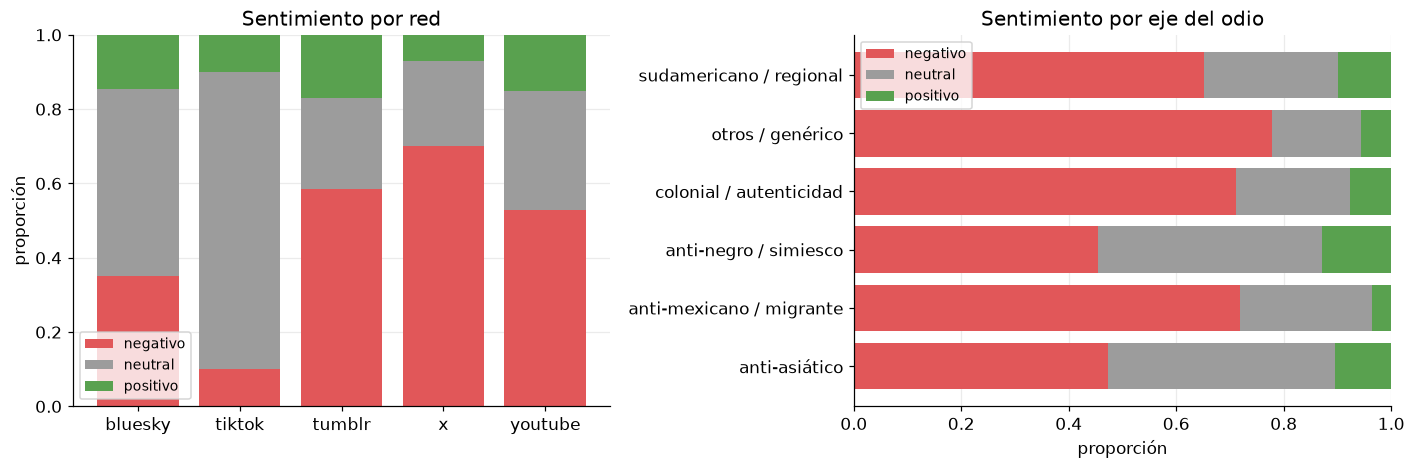

In [7]:
print("Sentimiento global:", out["sentimiento"].value_counts().to_dict())
if "odio" in out.columns and out["odio"].notna().any():
    print(f"Marcados 'hateful': {int(out['odio'].fillna(False).sum()):,} "
          f"de {int(out['odio'].notna().sum()):,} evaluados")

# Distribución de sentimiento por red (proporción apilada).
orden_sent = ["negativo", "neutral", "positivo"]
tab = (out.groupby("red")["sentimiento"].value_counts(normalize=True)
       .unstack(fill_value=0).reindex(columns=orden_sent, fill_value=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
base = [0] * len(tab)
for s in orden_sent:
    ax1.bar(tab.index, tab[s], bottom=base, label=s, color=COLOR_SENT[s])
    base = [b + v for b, v in zip(base, tab[s])]
ax1.set_ylabel("proporción"); ax1.set_ylim(0, 1)
ax1.set_title("Sentimiento por red"); ax1.legend(fontsize=9)

# Sentimiento por eje del odio (solo textos con eje marcado).
if "ejes" in out.columns:
    filas = [(e, s) for ejes, s in zip(out["ejes"], out["sentimiento"])
             if isinstance(ejes, list) for e in ejes]
    if filas:
        ejx = pd.DataFrame(filas, columns=["eje", "sentimiento"])
        tab2 = (ejx.groupby("eje")["sentimiento"].value_counts(normalize=True)
                .unstack(fill_value=0).reindex(columns=orden_sent, fill_value=0))
        base = [0] * len(tab2)
        for s in orden_sent:
            ax2.barh(tab2.index, tab2[s], left=base, label=s, color=COLOR_SENT[s])
            base = [b + v for b, v in zip(base, tab2[s])]
        ax2.set_xlabel("proporción"); ax2.set_xlim(0, 1)
        ax2.set_title("Sentimiento por eje del odio"); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()